In [2]:
import pandas as pd

df = pd.read_csv(r"E:\bike sharing task(7 July)\Notebook\SeoulBikeData.csv",encoding="unicode_escape")

df.head()

C:\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,Date,Rented Bike Count,Hour,Temperature(ï¿½C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(ï¿½C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [3]:
df.shape

(8760, 14)

In [4]:
df.columns


Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(ï¿½C)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(ï¿½C)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day'],
      dtype='str')

In [5]:
df = df.rename(columns={"Temperature(ï¿½C)" : "Temperature_C", "Dew point temperature(ï¿½C)" : "Dew point temperature_C"})

In [6]:
df["Holiday"].value_counts()

Holiday
No Holiday    8328
Holiday        432
Name: count, dtype: int64

In [7]:
df["Seasons"].value_counts()

Seasons
Spring    2208
Summer    2208
Autumn    2184
Winter    2160
Name: count, dtype: int64

In [8]:
df["Functioning Day"].value_counts()

Functioning Day
Yes    8465
No      295
Name: count, dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     8760 non-null   str    
 1   Rented Bike Count        8760 non-null   int64  
 2   Hour                     8760 non-null   int64  
 3   Temperature_C            8760 non-null   float64
 4   Humidity(%)              8760 non-null   int64  
 5   Wind speed (m/s)         8760 non-null   float64
 6   Visibility (10m)         8760 non-null   int64  
 7   Dew point temperature_C  8760 non-null   float64
 8   Solar Radiation (MJ/m2)  8760 non-null   float64
 9   Rainfall(mm)             8760 non-null   float64
 10  Snowfall (cm)            8760 non-null   float64
 11  Seasons                  8760 non-null   str    
 12  Holiday                  8760 non-null   str    
 13  Functioning Day          8760 non-null   str    
dtypes: float64(6), int64(4), str(4)
mem

In [11]:
df.describe()

,Rented Bike Count,Hour,Temperature_C,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature_C,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [12]:
df.isnull().sum()

Date                       0
Rented Bike Count          0
Hour                       0
Temperature_C              0
Humidity(%)                0
Wind speed (m/s)           0
Visibility (10m)           0
Dew point temperature_C    0
Solar Radiation (MJ/m2)    0
Rainfall(mm)               0
Snowfall (cm)              0
Seasons                    0
Holiday                    0
Functioning Day            0
dtype: int64

In [13]:
df.isna().sum()

Date                       0
Rented Bike Count          0
Hour                       0
Temperature_C              0
Humidity(%)                0
Wind speed (m/s)           0
Visibility (10m)           0
Dew point temperature_C    0
Solar Radiation (MJ/m2)    0
Rainfall(mm)               0
Snowfall (cm)              0
Seasons                    0
Holiday                    0
Functioning Day            0
dtype: int64

### Analyzing the traget variable

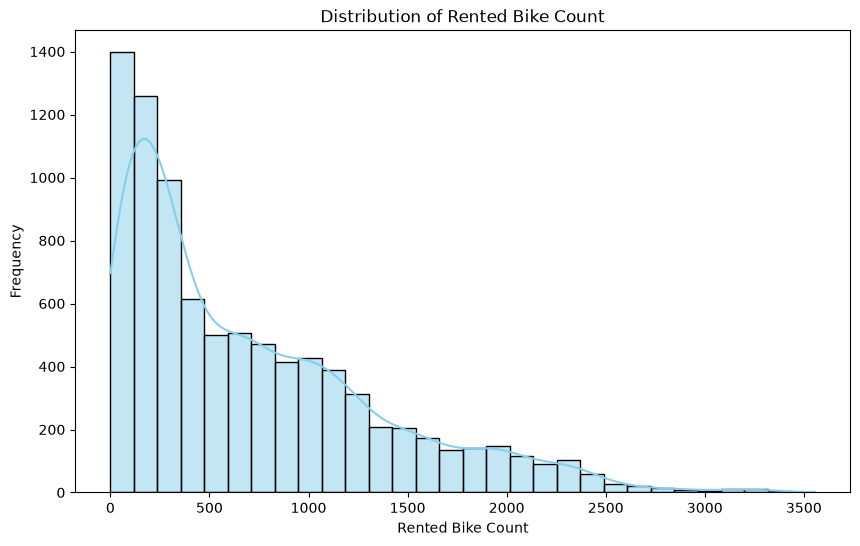

Skewness of Rented Bike Count: 1.153
Kurtosis: 0.8533869902003848


In [14]:

import matplotlib.pyplot as plt
import seaborn as sns


skewness = df["Rented Bike Count"].skew()


plt.figure(figsize=(10, 6))

sns.histplot(
    df["Rented Bike Count"],
    bins=30,
    kde=True,
    color="skyblue",
    edgecolor="black"
)

plt.title("Distribution of Rented Bike Count")
plt.xlabel("Rented Bike Count")
plt.ylabel("Frequency")

plt.show()


print(f"Skewness of Rented Bike Count: {skewness:.3f}")
kurtosis = df["Rented Bike Count"].kurt()

print("Kurtosis:", kurtosis)

### Visualising the realtion with the heatmap

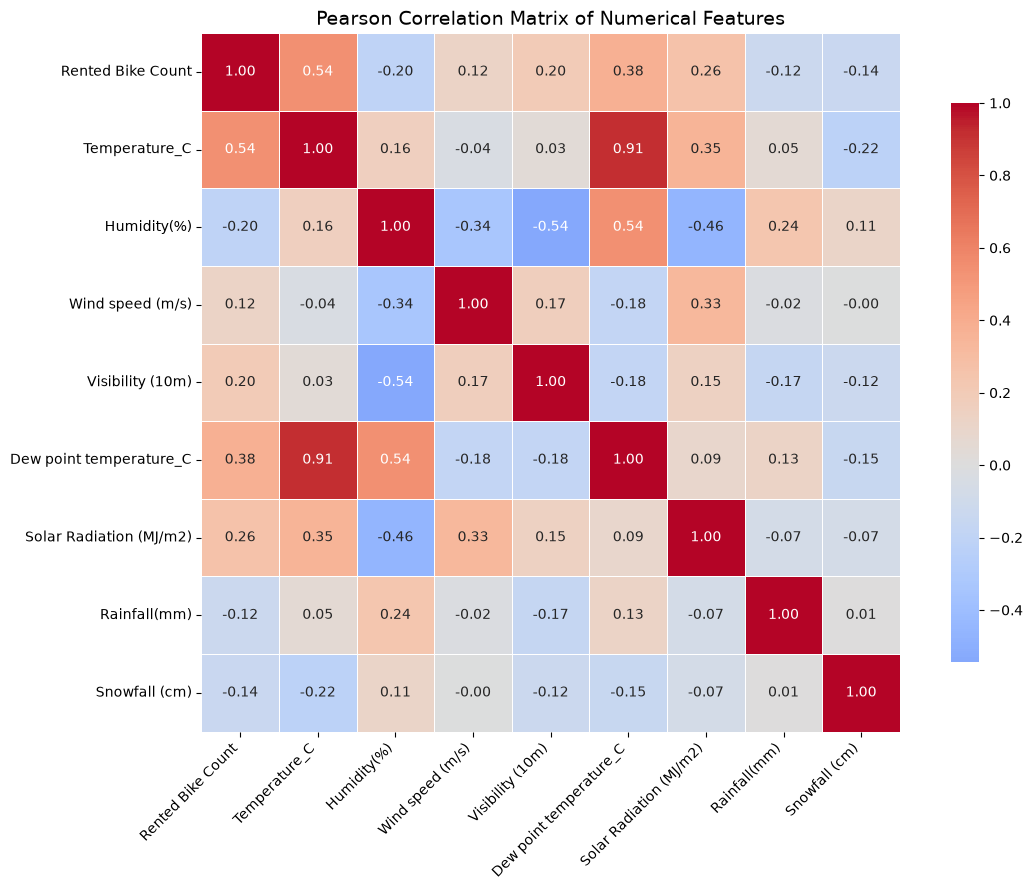

In [15]:
numerical_features = [
    "Rented Bike Count",
    "Temperature_C",
    "Humidity(%)",
    "Wind speed (m/s)",
    "Visibility (10m)",
    "Dew point temperature_C",
    "Solar Radiation (MJ/m2)",
    "Rainfall(mm)",
    "Snowfall (cm)"
]

df_numeric = df[numerical_features]

correlation_matrix = df_numeric.corr(method="pearson")

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,         
    fmt=".2f",         
    cmap="coolwarm",    
    center=0,           
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Pearson Correlation Matrix of Numerical Features", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#### Here the 2 features are highly related with the target feature Temperature_C and Dew point temperature_C 

In [16]:
import numpy as np
df["Rented Bike Count Sqrt"] = np.sqrt(df["Rented Bike Count"])

print(df["Rented Bike Count Sqrt"].skew())
print(df["Rented Bike Count Sqrt"].kurt())

0.237362090985412
-0.6572011997861553


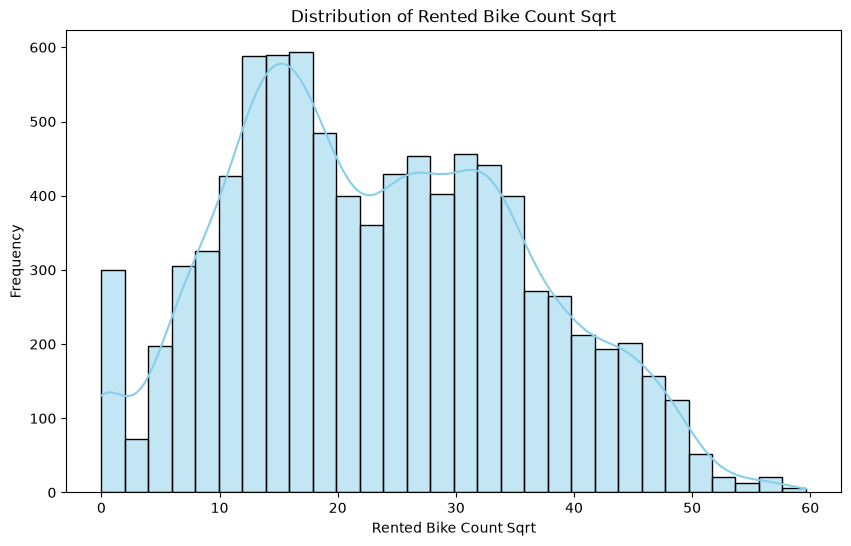

Skewness of Rented Bike Count: 0.237
Kurtosis: -0.6572011997861553


In [17]:
skewness = df["Rented Bike Count Sqrt"].skew()


plt.figure(figsize=(10, 6))

sns.histplot(
    df["Rented Bike Count Sqrt"],
    bins=30,
    kde=True,
    color="skyblue",
    edgecolor="black"
)

plt.title("Distribution of Rented Bike Count Sqrt")
plt.xlabel("Rented Bike Count Sqrt")
plt.ylabel("Frequency")

plt.show()


print(f"Skewness of Rented Bike Count: {skewness:.3f}")
kurtosis = df["Rented Bike Count Sqrt"].kurt()

print("Kurtosis:", kurtosis)

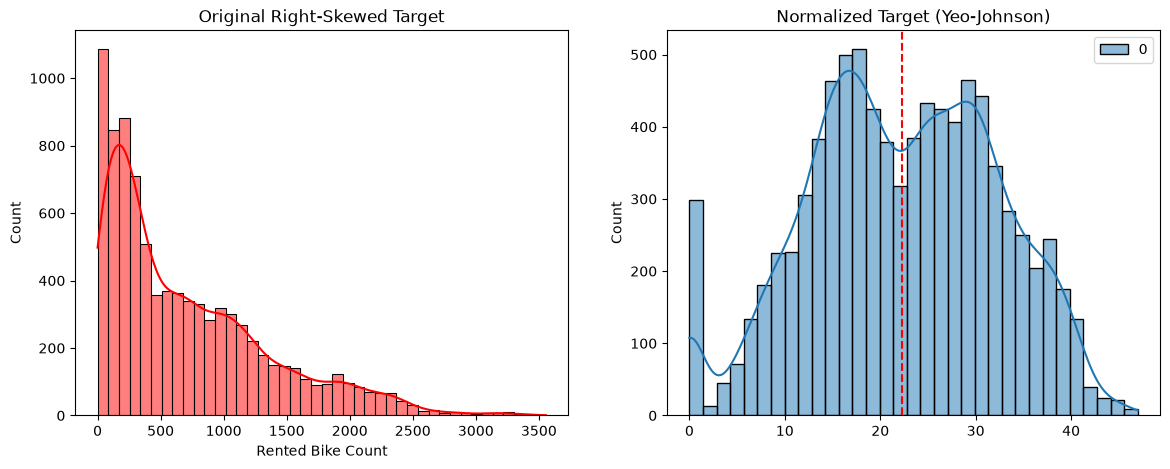

Optimal Lambda found: 0.3495


In [ ]:
from sklearn.preprocessing import PowerTransformer

pt_yj = PowerTransformer(method='yeo-johnson', standardize=False)

target_raw = df['Rented Bike Count'].values.reshape(-1, 1)

target_yj = pt_yj.fit_transform(target_raw)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Rented Bike Count'], kde=True, ax=axes[0], color='red')
axes[0].set_title('Original Right-Skewed Target')

sns.histplot(target_yj, kde=True, ax=axes[1], color='green')
axes[1].set_title('Normalized Target (Yeo-Johnson)')

mean = target_yj.mean()

axes[1].axvline(mean, color='red', linestyle='--')

plt.show()

print(f"Optimal Lambda found: {pt_yj.lambdas_[0]:.4f}")

##### The original Rented Bike Count variable exhibited moderate positive skewness (1.153). A log transformation over-corrected the distribution, resulting in negative skewness (-1.832) and higher kurtosis (4.339). A square root transformation reduced the skewness to 0.237 and the kurtosis to -0.657, yielding a distribution that is much closer to normal. Therefore, the square root transformation was selected.

### Ploting the histogram and Boxplot for all numerical Feature for outlier detection

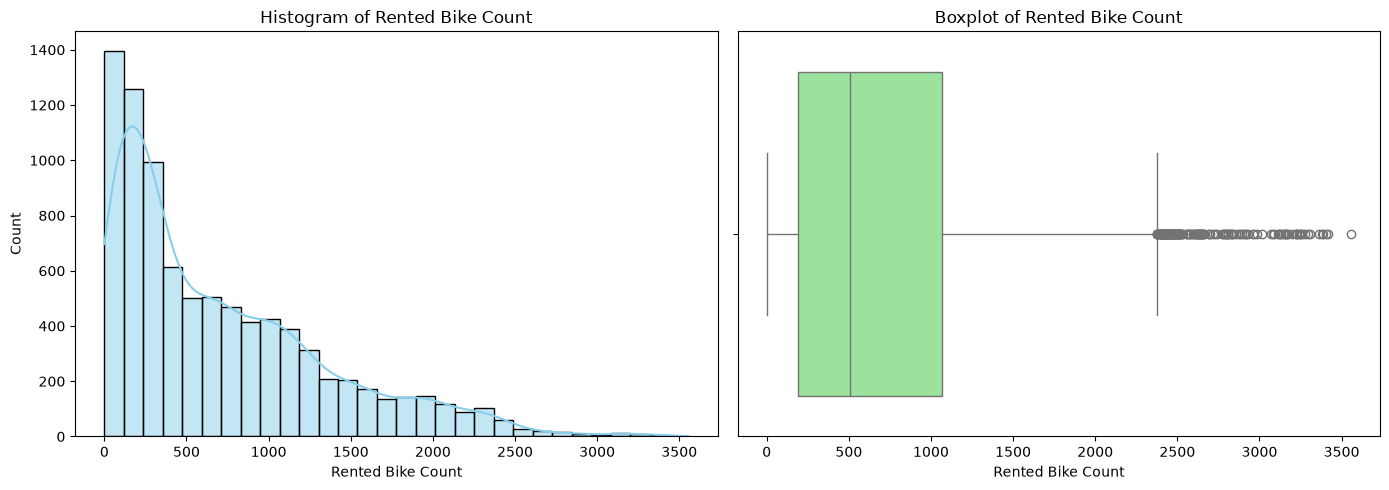

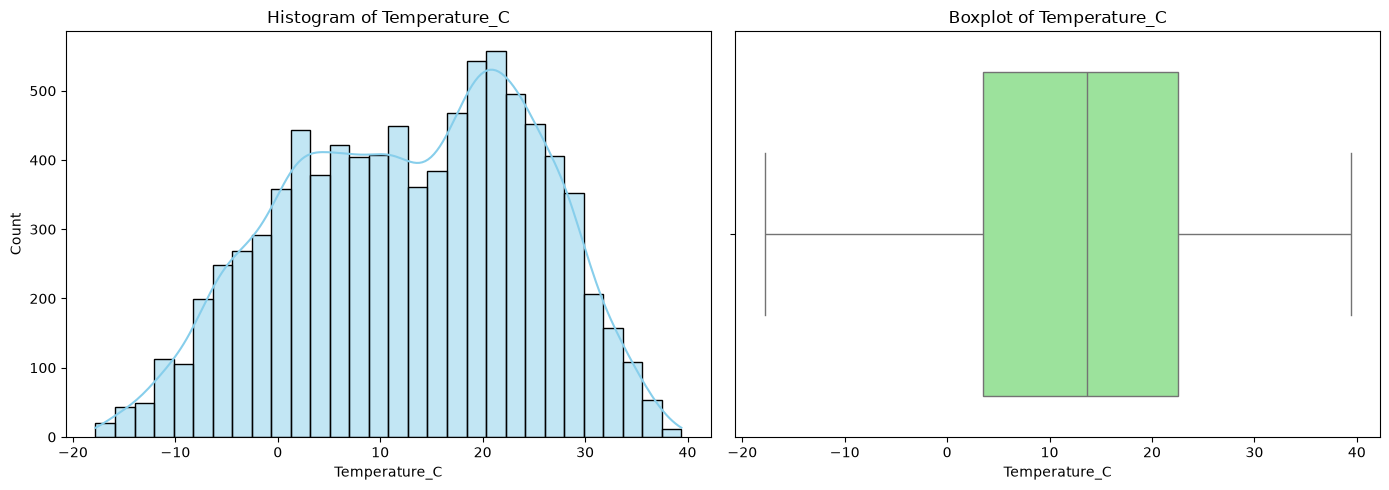

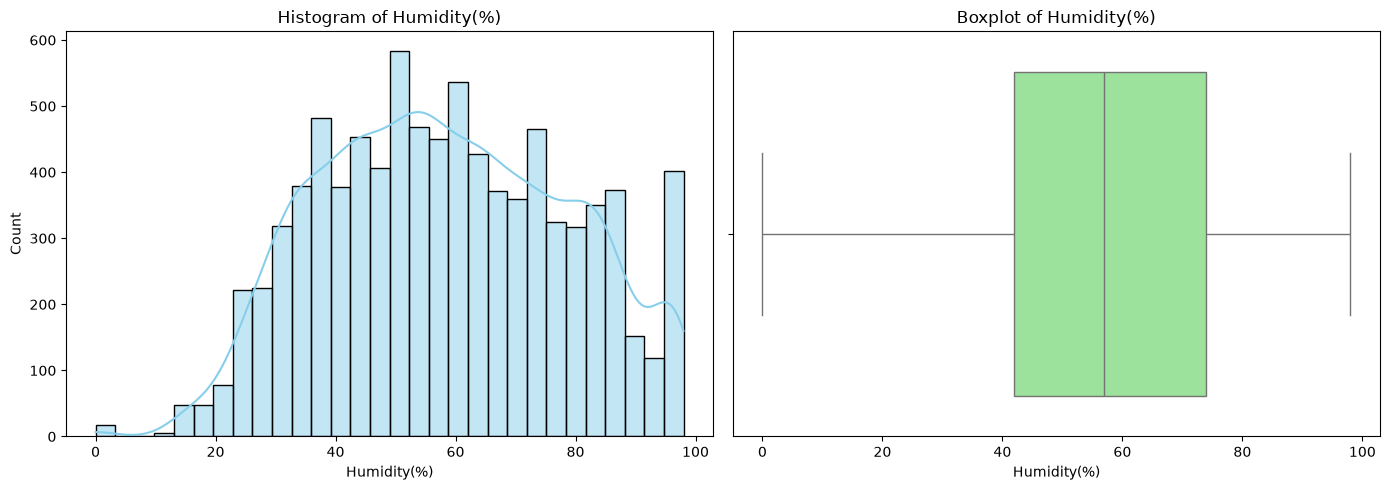

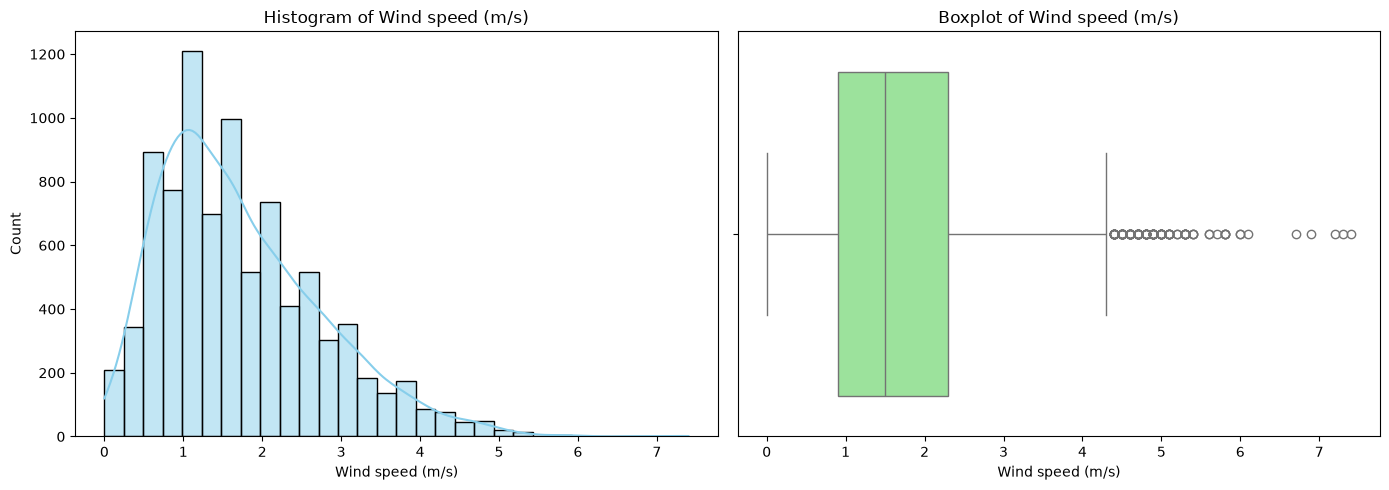

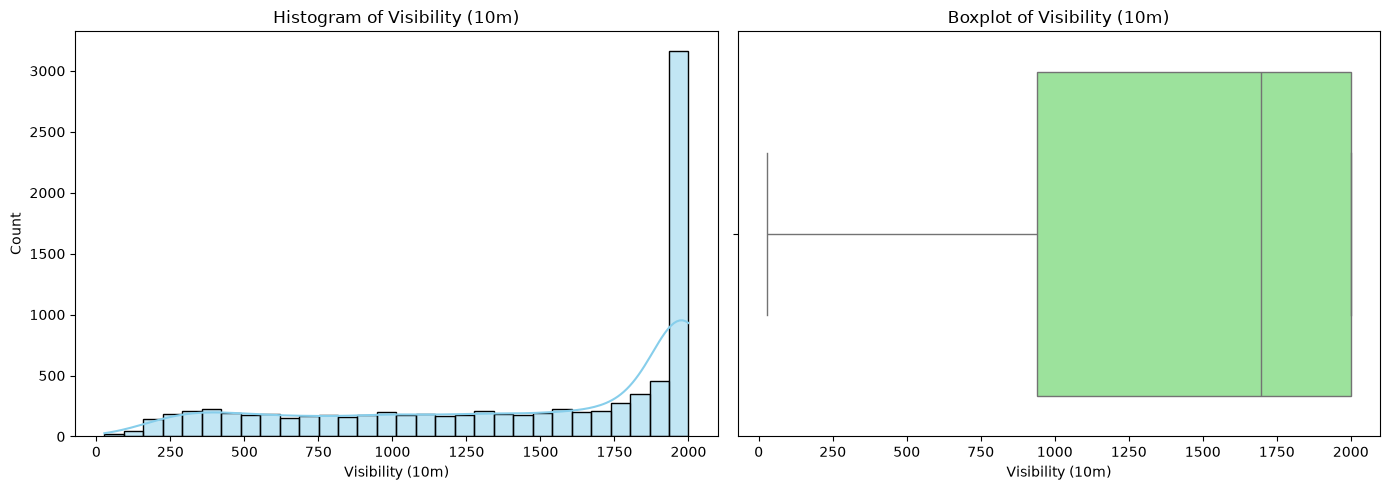

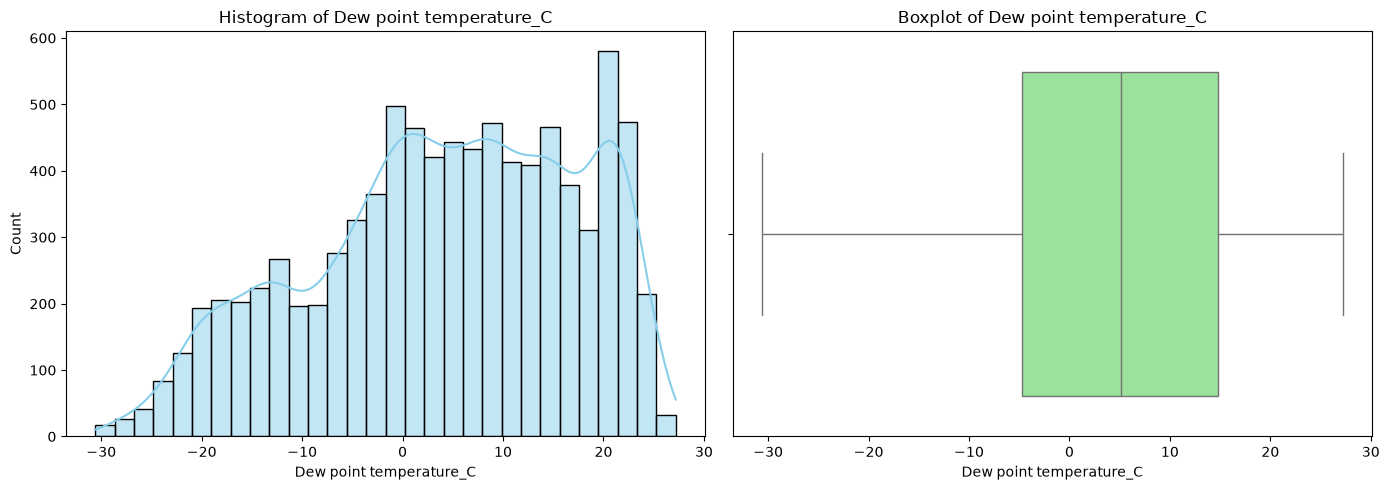

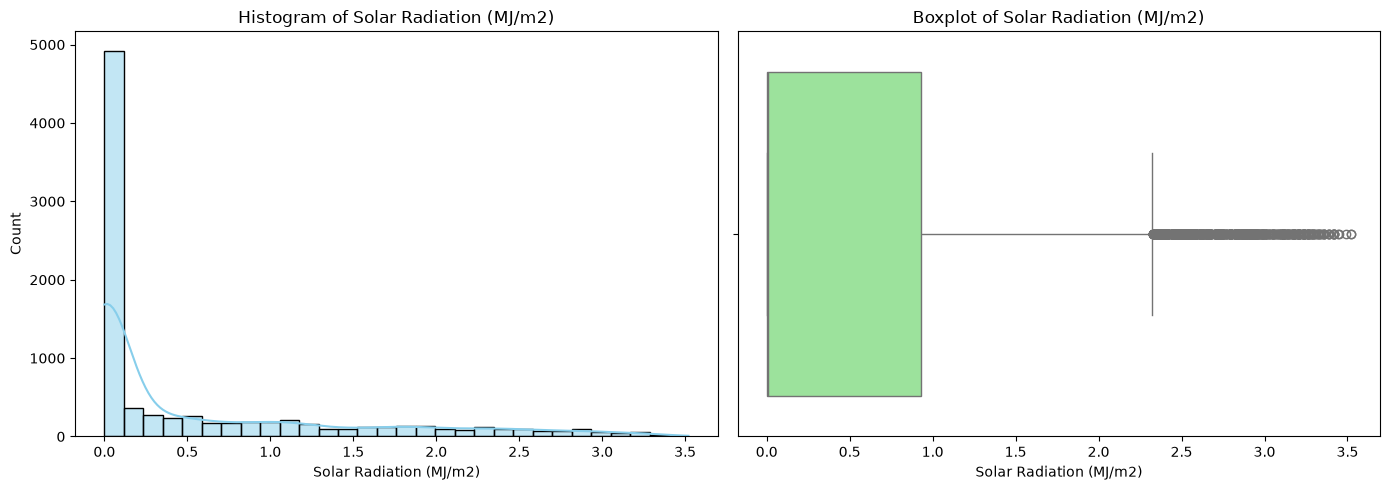

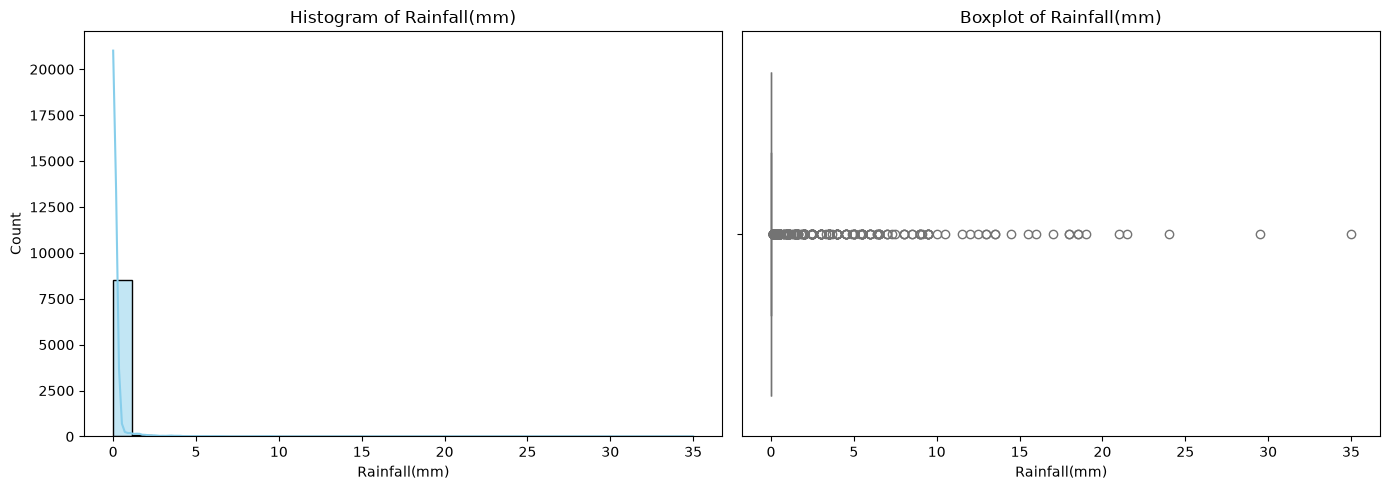

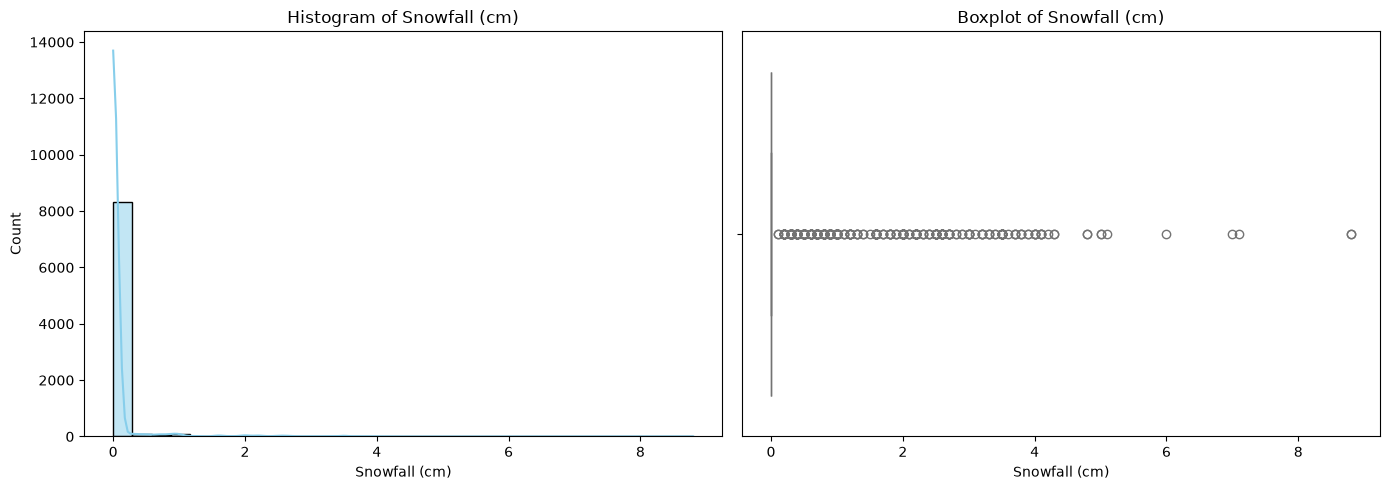

In [18]:
for col in numerical_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df[col], bins=30, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Histogram of {col}')

    sns.boxplot(x=df[col], ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

In [19]:
non_functional_day = df[df["Functioning Day"] == "No"]

if (non_functional_day['Rented Bike Count'] == 0).all():
    print("Rented Bike Count is always 0 when Functioning Day = 'No'.")

Rented Bike Count is always 0 when Functioning Day = 'No'.


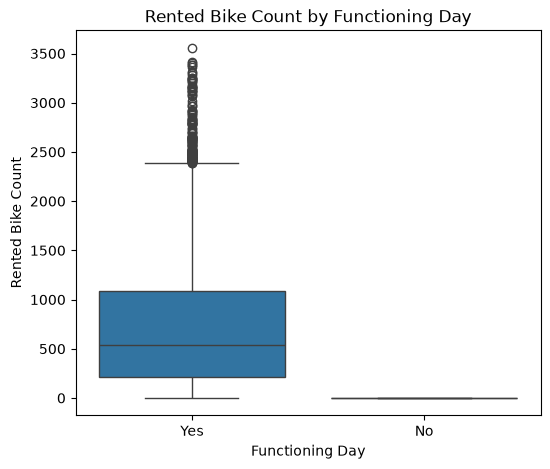

In [20]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df,
            x='Functioning Day',
            y='Rented Bike Count')

plt.title('Rented Bike Count by Functioning Day')
plt.show()

Here the bike rental count is always zero in a NON functional day so probably we can remove this rows where functional day is "NO" and then just keep the data which only have to functional day as "YES" then map those as 1 or else we can remove them also 

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")

df["Day"] = df["Date"].dt.day
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year
df["day_of_week"] = df["Date"].dt.dayofweek 

In [22]:
No_rentals = df[
    (df["Functioning Day"] == "Yes") &
    (df["Rented Bike Count"] == 0)
]
print(len(No_rentals))

0


### Time based analysis like day and month

In [23]:
df.columns

Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature_C', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature_C',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day', 'Rented Bike Count Sqrt', 'Day', 'Month',
       'Year', 'day_of_week'],
      dtype='str')

In [24]:
df.head()

,Date,Rented Bike Count,Hour,Temperature_C,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature_C,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Rented Bike Count Sqrt,Day,Month,Year,day_of_week
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,15.937377,1,12,2017,4
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,14.282857,1,12,2017,4
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,13.152946,1,12,2017,4
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,10.344080,1,12,2017,4
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,8.831761,1,12,2017,4


In [25]:
df["Hour"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

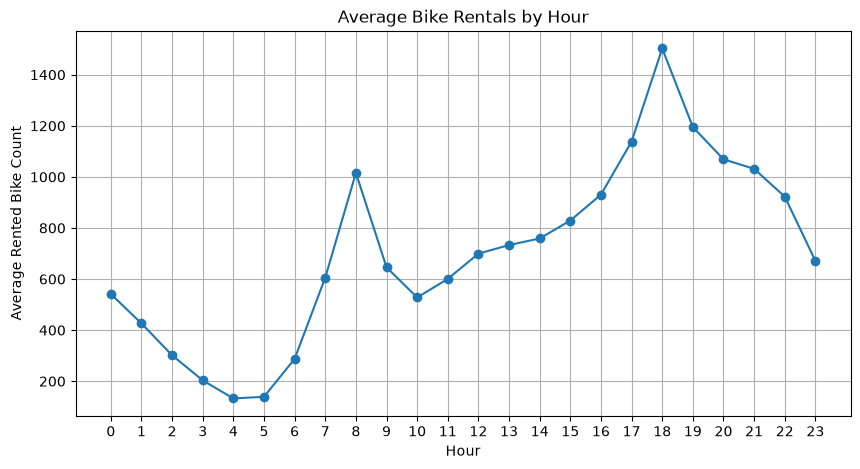

In [26]:
hourly_avg = df.groupby("Hour")["Rented Bike Count"].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_avg.index, hourly_avg.values, marker="o")
plt.xticks(range(24))
plt.xlabel("Hour")
plt.ylabel("Average Rented Bike Count")
plt.title("Average Bike Rentals by Hour")
plt.grid(True)
plt.show()

##### Here the first maxima is a the 8AM and is a non-functioning day as we described before and the peak value is at 6PM 

### Rented the bike count based on the seasons 

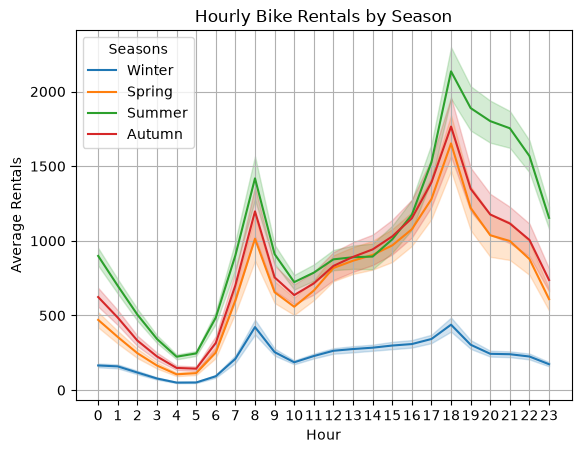

In [27]:
sns.lineplot(
    data = df,
    x = "Hour",
    y = "Rented Bike Count",
    hue= "Seasons",
    estimator="mean",
    markers="o"
)
plt.xticks(range(24))
plt.title("Hourly Bike Rentals by Season")
plt.xlabel("Hour")
plt.ylabel("Average Rentals")
plt.grid(True)
plt.show()

### Maping the day to count the values of bike rented on the week days 

In [28]:
day_name = day_names = {
    0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu",
    4: "Fri", 5: "Sat", 6: "Sun"
}
df["day_name"] = df["day_of_week"].map(day_names)

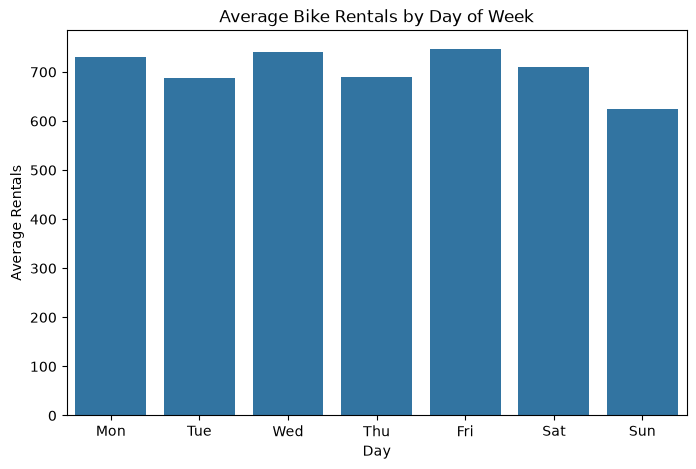

In [29]:
weekday_avg = (
    df.groupby(["day_of_week", "day_name"])["Rented Bike Count"]
      .mean()
      .reset_index()
      .sort_values("day_of_week")
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=weekday_avg,
    x="day_name",
    y="Rented Bike Count"
)

plt.title("Average Bike Rentals by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Rentals")
plt.show()

#### There are identical rentals in every week days 

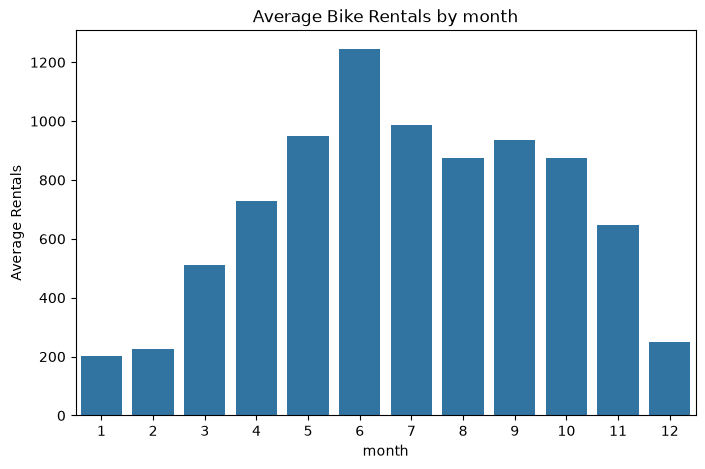

In [30]:
monthly_avg = (
    df.groupby(["Month"])["Rented Bike Count"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=monthly_avg,
    x="Month",
    y="Rented Bike Count"
)

plt.title("Average Bike Rentals by month")
plt.xlabel("month")
plt.ylabel("Average Rentals")
plt.show()

#### Here we can see that the maximum rental we got in the 6 month

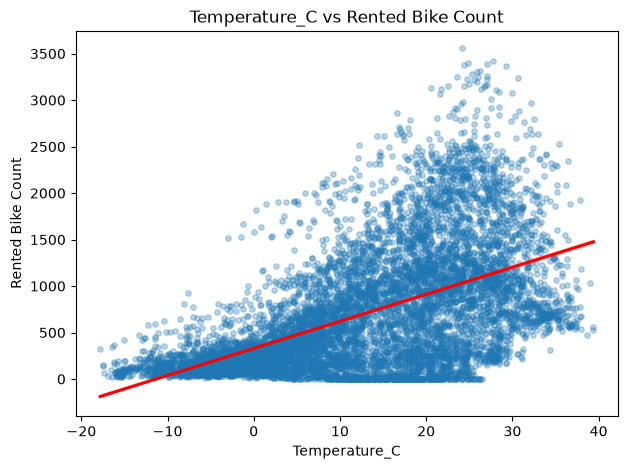

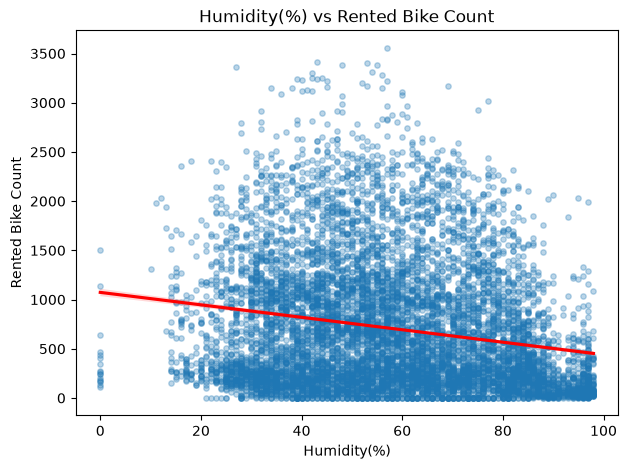

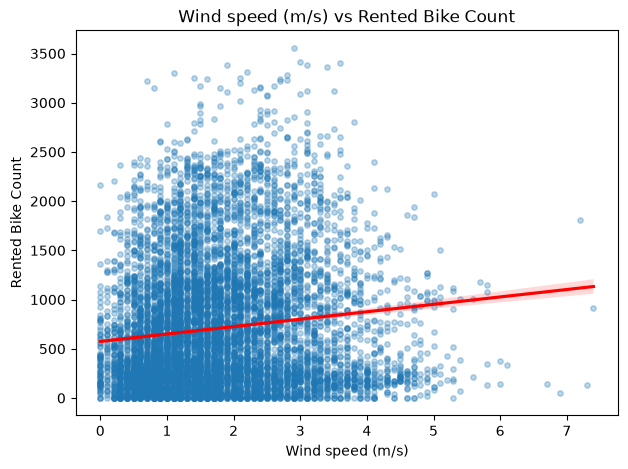

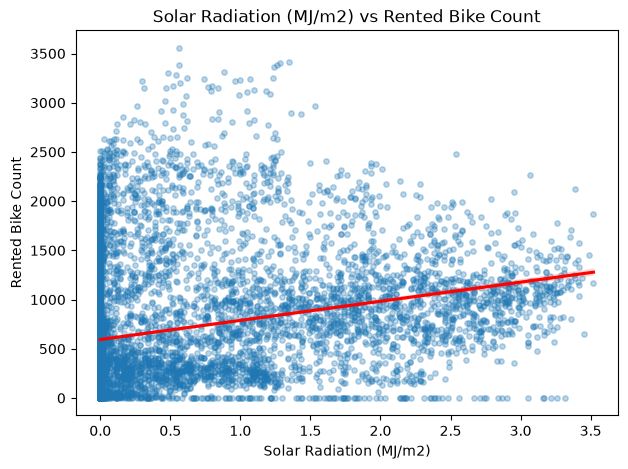

In [31]:
features = [
    "Temperature_C",
    "Humidity(%)",
    "Wind speed (m/s)",
    "Solar Radiation (MJ/m2)"
]

for feature in features:
    plt.figure(figsize=(7,5))

    sns.regplot(
        data=df,
        x=feature,
        y="Rented Bike Count",
        scatter_kws={"alpha":0.3, "s":15},
        line_kws={"color":"red"},
      
    )

    plt.title(f"{feature} vs Rented Bike Count")
    plt.xlabel(feature)
    plt.ylabel("Rented Bike Count")
    plt.show()

Here we can see that the weather conditions and the rental bike are not always in a linear type. Because here the humidity increase but not the rental count same applys upon the wind speed. So based on this we can analyse that tree based models are more sutaible then linear model. The models like RandomForest and XGBoost will perform better then any linear model

### Business Understanding

##### Here the first peak hour is at 8AM in the morning where the people rent the bike and the second peak hour is at 6PM in the evening where same reverse senario happens when the people returns home 

##### This model is helpful to load to the station with the help of predicting the peak hours before a stockout happens. Useful for the ground co-workers
